In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable
from astropy.table import Table

filename_path = '../data/astraAllStarASPCAP-0.7.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[2].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

['sdss5_target_flags']


This is the query I used to get the IDs of stars with rvs and SNR > 100:

```sql
SELECT 
  source_id, ra, dec, parallax, pmra, pmdec, 
  radial_velocity, rvs_spec_sig_to_noise, 
  teff_gspphot, logg_gspphot, mh_gspphot
FROM gaiadr3.gaia_source
WHERE has_rvs = 'True' 
  AND rvs_spec_sig_to_noise > 100

In [ ]:
gaia_table = Table.read('all_rvs_AI-result.vot', format='votable')

# Convert the astropy Table to a pandas DataFrame
gaia_df = gaia_table.to_pandas()

# Verify the data loaded correctly

print("number of stars = ", len(gaia_df))

number of stars =  120520


## 1. Filter on Teff between 4500 and 6500

In [24]:
# Filter on temperature (not sure if we need this?)

gaia_df = gaia_df[(gaia_df['teff_gspphot'] > 4500) & (gaia_df['teff_gspphot'] < 6500)]
print("n_stars = ", len(gaia_df))

n_stars =  41293


## 2. Drop duplicates if any

In [26]:
gaia_df = gaia_df.sort_values(['rvs_spec_sig_to_noise'], ascending=False)
gaia_df = gaia_df.drop_duplicates(subset='SOURCE_ID', keep='first')

print("n_stars = ", len(gaia_df))

n_stars =  41293


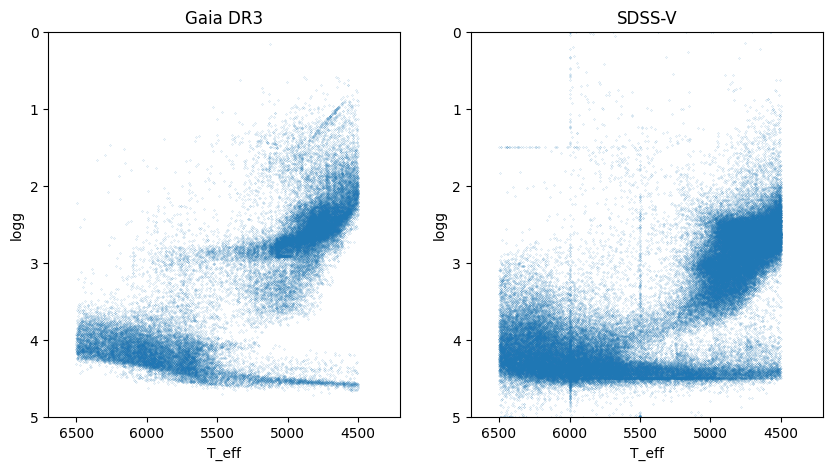

In [21]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Gaia DR3")
plt.scatter(gaia_df['teff_gspphot'], gaia_df['logg_gspphot'], s = 0.01)
plt.xlim(4200,6700)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.title("SDSS-V")
plt.scatter(df_sdss5['teff'], df_sdss5['logg'], s = 0.01)
plt.xlim(4200,6700)
plt.ylim(0,5)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

## 3. Giants: 1.5 < logg < 3.5 and Dwarfs: logg > 3.5

In [22]:
giants_gaia = gaia_df[(gaia_df['logg_gspphot'] < 3.5) & (gaia_df['logg_gspphot'] > 1.5)]
dwarfs_gaia = gaia_df[(gaia_df['logg_gspphot'] > 3.5)]

print("number of giants = ", len(giants_gaia))
print("number of dwarfs = ", len(dwarfs_gaia))

number of giants =  23918
number of dwarfs =  16549


## 4. Save their IDs to download their RVS

In [28]:
giants_gaia['SOURCE_ID'].to_csv("all_gaia_giants_IDs.txt", index=False, header=False)
dwarfs_gaia['SOURCE_ID'].to_csv("all_dwarfs_IDs.txt", index=False, header=False)

In [29]:
# Convert the DataFrames to Astropy Tables (keeping the SOURCE_ID column name)
giants_table = Table.from_pandas(giants_gaia[['SOURCE_ID']])
dwarfs_table = Table.from_pandas(dwarfs_gaia[['SOURCE_ID']])

# Save them as VOTable files
giants_table.write("all_gaia_giants_IDs.vot", format="votable", overwrite=True)
dwarfs_table.write("all_dwarfs_IDs.vot", format="votable", overwrite=True)

In [30]:
giants_table

SOURCE_ID
int64
21503187559666176
39243567157484544
41201178891455872
52785530322396288
58498042983926400
64976743452464128
66640201466940928
77643353625483392
104879154294136192


## 5. Download their RVS

for this step, login to gaia AIP:

https://gaia.aip.de/

Go to query, then upload your vot table.
Then, use this query:

SELECT rvs.*
FROM "gaiadr3"."rvs_mean_spectrum" AS rvs
JOIN "gaia_user_htajer"."all_gaia_giants" AS mytargets ON mytargets."SOURCE_ID" = rvs.source_id

and change name of table based on your table name.

The, download the data as XML.

## 6. Read the csv file

Text(0, 0.5, 'Flux')

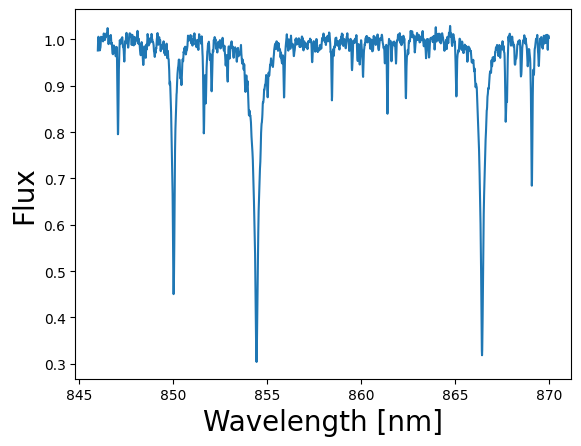

In [32]:
lambdas = np.linspace(846, 870, 2401)

t_giants = Table.read("../data/giants_rvs_2.xml", format="votable")
t_dwarfs = Table.read("../data/dwarfs_rvs.xml", format="votable")

rvs_giants_df = t_giants.to_pandas()
rvs_dwarfs_df = t_dwarfs.to_pandas()

Text(0, 0.5, 'Flux')

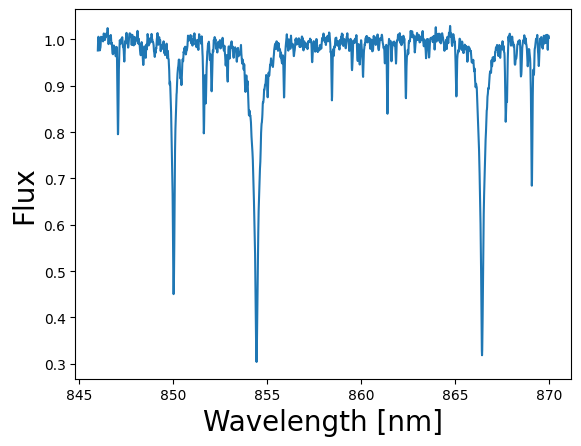

In [33]:
eg_giant = rvs_giants_df.iloc[0]

plt.plot(lambdas, eg_giant['flux'])
plt.xlabel('Wavelength [nm]', fontsize=20)
plt.ylabel('Flux', fontsize=20)

## 7. Only keep flux and flux errors

In [35]:
rvs_giants_df.head()

,datalinkID,solution_id,ra,dec,flux,flux_error,combined_transits,combined_ccds,deblended_ccds
0,120190364960512,5950420259779346465,45.007994,0.888562,"[0.97617275, 0.9893797, 1.0023663, 1.0058981, ...","[0.009097856, 0.008392963, 0.008817549, 0.0081...",11,30,8
1,18843400212644992,5950420259779346465,41.302994,7.472149,"[0.9741285, 0.96930116, 0.96988595, 0.97027916...","[0.008364747, 0.01039784, 0.009786651, 0.00897...",8,22,12
2,21416944616403584,5950420259779346465,40.651476,8.747850,"[0.97164625, 0.95944184, 0.9554867, 0.96302944...","[0.007859042, 0.00802331, 0.009169706, 0.00894...",12,33,3
3,21503187559666176,5950420259779346465,40.652843,9.124059,"[0.9786615, 0.9803057, 0.98323566, 0.98647726,...","[0.007597014, 0.005691464, 0.006939424, 0.0078...",11,30,13
4,50081418913079424,5950420259779346465,59.178103,19.154350,"[0.9695344, 0.9571425, 0.95540315, 0.96446687,...","[0.009017859, 0.008820456, 0.0110681895, 0.012...",22,63,7


In [36]:
rvs_giants_df_flux = rvs_giants_df[['datalinkID', 'flux', 'flux_error']].copy()
rvs_giants_df_flux['source_id'] = rvs_giants_df_flux['datalinkID']
rvs_giants_df_flux.head()

,datalinkID,flux,flux_error,source_id
0,120190364960512,"[0.97617275, 0.9893797, 1.0023663, 1.0058981, ...","[0.009097856, 0.008392963, 0.008817549, 0.0081...",120190364960512
1,18843400212644992,"[0.9741285, 0.96930116, 0.96988595, 0.97027916...","[0.008364747, 0.01039784, 0.009786651, 0.00897...",18843400212644992
2,21416944616403584,"[0.97164625, 0.95944184, 0.9554867, 0.96302944...","[0.007859042, 0.00802331, 0.009169706, 0.00894...",21416944616403584
3,21503187559666176,"[0.9786615, 0.9803057, 0.98323566, 0.98647726,...","[0.007597014, 0.005691464, 0.006939424, 0.0078...",21503187559666176
4,50081418913079424,"[0.9695344, 0.9571425, 0.95540315, 0.96446687,...","[0.009017859, 0.008820456, 0.0110681895, 0.012...",50081418913079424


In [37]:
rvs_dwarfs_df_flux = rvs_dwarfs_df[['datalinkID', 'flux', 'flux_error']].copy()
rvs_dwarfs_df_flux['source_id'] = rvs_dwarfs_df_flux['datalinkID']
rvs_dwarfs_df_flux.head()

,datalinkID,flux,flux_error,source_id
0,42344224307737088,"[0.98444444, 0.9909175, 0.9967685, 1.0045131, ...","[0.008072018, 0.007372704, 0.0082370825, 0.008...",42344224307737088
1,46554219970453888,"[0.9939969, 0.9962654, 0.99605775, 0.994744, 0...","[0.0050835586, 0.004803717, 0.0049417387, 0.00...",46554219970453888
2,48026637838306432,"[0.99911326, 0.99675226, 0.98396254, 0.9744301...","[0.008667585, 0.0072521064, 0.007336599, 0.007...",48026637838306432
3,48197783694869760,"[1.0052587, 1.0051451, 1.0033542, 1.0022495, 1...","[0.0062676766, 0.0060000177, 0.007055512, 0.00...",48197783694869760
4,53661806730081792,"[1.0047868, 1.0012465, 0.99102604, 0.9866357, ...","[0.016753009, 0.014152305, 0.012628556, 0.0151...",53661806730081792


In [38]:
rvs_giants_df_flux.to_pickle('../data/all_giants_rvs_fluxes.pkl')
rvs_dwarfs_df_flux.to_pickle('../data/all_dwarfs_rvs_fluxes.pkl')